In [2]:
# import libraries
import pandas as pd
import numpy as np

In [3]:
# Utility Functions

from scipy.stats import spearmanr, chi2_contingency
import numpy as np
import pandas as pd

def spearman_with_p(series_a, series_b):
    """Return (rho, p_value) for two series, dropping NaN pairs."""
    clean = pd.DataFrame({'a': series_a, 'b': series_b}).dropna()
    rho, p = spearmanr(clean['a'], clean['b'])
    return round(rho, 4), round(p, 6)

def contingency_c(series_a, series_b):
    """Calculate Pearson's Contingency Coefficient C from two series."""
    clean = pd.DataFrame({'a': series_a, 'b': series_b}).dropna()
    table = pd.crosstab(clean['a'].astype(int), clean['b'].astype(int))
    if table.empty or table.sum().sum() == 0 or min(table.shape) <= 1:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    n = clean.shape[0]
    return round(np.sqrt(chi2 / (n + chi2)), 4)

def bin_race_position(pos):
    """Bin a numeric race position into an ordinal category."""
    if pos <= 3:
        return 'Podium (1-3)'
    elif pos <= 10:
        return 'Points (4-10)'
    else:
        return 'Outside Points (11+)'

In [4]:
#Load the raw datasets
practices_df = pd.read_csv('../data/raw/f1_results_practices.csv')
qualifying_df = pd.read_csv('../data/raw/f1_results_qualifications.csv')
races_df = pd.read_csv('../data/raw/f1_results_races.csv')
starting_grid_df = pd.read_csv('../data/raw/f1_starting_grid.csv')

#Display first 5 rows to verify data loaded correctly
practices_df.head()

,season,GP,gp_code,session,Unnamed: 0,Pos,No,Driver,Car,Time,Gap,Laps,Unnamed: 8,Offset
0,2023,bahrain,1141,practice-1,NaN,1,11,Sergio Perez PER,Red Bull Racing Honda RBPT,01:32.8,NaN,21,NaN,NaN
1,2023,bahrain,1141,practice-1,NaN,2,14,Fernando Alonso ALO,Aston Martin Aramco Mercedes,01:33.2,+0.438s,22,NaN,NaN
2,2023,bahrain,1141,practice-1,NaN,3,1,Max Verstappen VER,Red Bull Racing Honda RBPT,01:33.4,+0.617s,21,NaN,NaN
3,2023,bahrain,1141,practice-1,NaN,4,4,Lando Norris NOR,McLaren Mercedes,01:34.2,+1.407s,21,NaN,NaN
4,2023,bahrain,1141,practice-1,NaN,5,16,Charles Leclerc LEC,Ferrari,01:34.3,+1.499s,17,NaN,NaN


In [5]:
# Standardise data types for merge keys
for df in [practices_df, qualifying_df, races_df, starting_grid_df]:
    df['No'] = pd.to_numeric(df['No'], errors='coerce')

### Preprocessing the 4 datasets one by one

In [6]:
# Preprocess and Pivot the Practices DataFrame
# Clean up session names
practices_df['session'] = practices_df['session'].str.replace('practice-', 'p')

# Keep only first 3 practice sessions
practices_df = practices_df[practices_df['session'].isin(['p1', 'p2', 'p3'])]

# pivot table to have one row per driver per GP
practice_pivot_df = practices_df.pivot_table(
    index = ['season', 'GP', 'gp_code', 'No', 'Driver', 'Car'],
    columns = 'session',
    values = ['Pos', 'Time', 'Laps', 'Gap'],
    aggfunc = 'first'  # In case of duplicates, take the first occurrence
).reset_index()

# Flatten MultiIndex columns ('Pos', 'p1') -> 'Pos_p1'
practice_pivot_df.columns = [f'{col[0]}_{col[1]}' 
                             if col[1] else col[0]
                             for col in practice_pivot_df.columns]

practice_pivot_df.head()

,season,GP,gp_code,No,Driver,Car,Gap_p1,Gap_p2,Gap_p3,Laps_p1,Laps_p2,Laps_p3,Pos_p1,Pos_p2,Pos_p3,Time_p1,Time_p2,Time_p3
0,2006,australia,792,1,Fernando Alonso ALO,Renault,None,+0.621s,+4.319s,2,14,11,19,5,17,None,1:27.443,1:39.654
1,2006,australia,792,2,Giancarlo Fisichella FIS,Renault,None,+1.458s,+1.079s,2,11,13,20,11,4,None,1:28.280,1:36.414
2,2006,australia,792,3,Kimi Räikkönen RAI,McLaren Mercedes,+0.454s,+0.951s,+12.949s,5,16,3,4,7,21,1:28.713,1:27.773,1:48.284
3,2006,australia,792,4,Juan Pablo Montoya MOY,McLaren Mercedes,None,+1.378s,+9.015s,1,15,3,22,9,20,None,1:28.200,1:44.350
4,2006,australia,792,5,Michael Schumacher MSC,Ferrari,+0.782s,+0.836s,+1.997s,5,16,10,6,6,7,1:29.041,1:27.658,1:37.332


In [7]:
# Preprocess Qualifying Data
# Select n rename columns
qualifying_processed_df = qualifying_df[['season', 'GP', 'gp_code', 'No', 'Driver', 'Car', 'Pos', 'Q1', 'Q2', 'Q3', 'Laps']].rename(
    columns={'Pos': 'Pos_q', 'Laps': 'Laps_q'}
)

qualifying_processed_df.head()

,season,GP,gp_code,No,Driver,Car,Pos_q,Q1,Q2,Q3,Laps_q
0,2023,bahrain,1141,1,Max Verstappen VER,Red Bull Racing Honda RBPT,1,1:31.295,1:30.503,1:29.708,15
1,2023,bahrain,1141,11,Sergio Perez PER,Red Bull Racing Honda RBPT,2,1:31.479,1:30.746,1:29.846,15
2,2023,bahrain,1141,16,Charles Leclerc LEC,Ferrari,3,1:31.094,1:30.282,1:30.000,17
3,2023,bahrain,1141,55,Carlos Sainz SAI,Ferrari,4,1:30.993,1:30.515,1:30.154,18
4,2023,bahrain,1141,14,Fernando Alonso ALO,Aston Martin Aramco Mercedes,5,1:31.158,1:30.645,1:30.336,15


In [8]:
# Preprocess Race Data
# Select n rename race data columns
races_processed_df = races_df[['season', 'GP', 'gp_code', 'No', 'Driver', 'Car', 'Pos', 'Laps', 'Time/Retired', 'PTS']].rename(
    columns = {'Pos': 'Pos_race', 'Laps': 'Laps_race'}   
)

# Create DNF flag BEFORE converting Pos_race to numeric
# In raw data, DNFs have non-numeric values like 'Ret', 'DNF', 'DSQ', 'NC' in the Pos column
races_processed_df['is_dnf'] = pd.to_numeric(races_processed_df['Pos_race'], errors='coerce').isna()

races_processed_df.head()

,season,GP,gp_code,No,Driver,Car,Pos_race,Laps_race,Time/Retired,PTS,is_dnf
0,2023,bahrain,1141,1.0,Max Verstappen VER,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,False
1,2023,bahrain,1141,11.0,Sergio Perez PER,Red Bull Racing Honda RBPT,2,57,+11.987s,18,False
2,2023,bahrain,1141,14.0,Fernando Alonso ALO,Aston Martin Aramco Mercedes,3,57,+38.637s,15,False
3,2023,bahrain,1141,55.0,Carlos Sainz SAI,Ferrari,4,57,+48.052s,12,False
4,2023,bahrain,1141,44.0,Lewis Hamilton HAM,Mercedes,5,57,+50.977s,10,False


In [9]:
# Preprocess Starting Grid Data
# select n rename starting grid columns
grid_processed_df = starting_grid_df[['season', 'GP', 'gp_code', 'No', 'Driver', 'Pos']].rename(
    columns = {'Pos' : 'Race_Start_pos'}
)

grid_processed_df.head()

,season,GP,gp_code,No,Driver,Race_Start_pos
0,2023,bahrain,1141,1.0,Max Verstappen VER,1
1,2023,bahrain,1141,11.0,Sergio Perez PER,2
2,2023,bahrain,1141,16.0,Charles Leclerc LEC,3
3,2023,bahrain,1141,55.0,Carlos Sainz SAI,4
4,2023,bahrain,1141,14.0,Fernando Alonso ALO,5


### Merging All Datasers into Final DataFrame

In [10]:
#Merging all datasets
merge_key = ['season', 'GP', 'gp_code', 'No', 'Driver']

#Start with race data as base using left join
final_df = pd.merge(races_processed_df , grid_processed_df, on = merge_key, how = 'left')

#Merge qualifying data
final_df = pd.merge(final_df, qualifying_processed_df.drop(columns = 'Car'), on = merge_key, how = 'left')

#Merge with the pivoted practice data
final_df = pd.merge(final_df, practice_pivot_df.drop(columns = 'Car'), on = merge_key, how = 'left')

#Display the final dataframe
final_df.head()

,season,GP,gp_code,No,Driver,Car,Pos_race,Laps_race,Time/Retired,PTS,...,Gap_p3,Laps_p1,Laps_p2,Laps_p3,Pos_p1,Pos_p2,Pos_p3,Time_p1,Time_p2,Time_p3
0,2023,bahrain,1141,1.0,Max Verstappen VER,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,...,+0.005s,21,24,13,3,2,2,01:33.4,01:31.1,01:32.3
1,2023,bahrain,1141,11.0,Sergio Perez PER,Red Bull Racing Honda RBPT,2,57,+11.987s,18,...,+0.106s,21,26,12,1,3,3,01:32.8,01:31.1,01:32.4
2,2023,bahrain,1141,14.0,Fernando Alonso ALO,Aston Martin Aramco Mercedes,3,57,+38.637s,15,...,None,22,25,13,2,1,1,01:33.2,01:30.9,01:32.3
3,2023,bahrain,1141,55.0,Carlos Sainz SAI,Ferrari,4,57,+48.052s,12,...,+0.605s,21,28,21,20,14,8,01:36.1,01:32.0,01:32.9
4,2023,bahrain,1141,44.0,Lewis Hamilton HAM,Mercedes,5,57,+50.977s,10,...,+0.215s,13,27,17,10,8,4,01:34.9,01:31.5,01:32.6


### Final Cleaning and Reordering 
Handling Missing Values

In [11]:
# Fill missing values (NaN) for lap times with a placeholder
for col in ['Q1', 'Q2', 'Q3', 'Time_p1', 'Time_p2', 'Time_p3']:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna('No Time')

# Coerce position columns to numeric
# keep NaN for missing/invalid values
# 0 is not a valid F1 position and corrupts correlation analysis
pos_cols = [col for col in final_df.columns if 'Pos' in col or '_q' in col or 'pos' in col]
for col in pos_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

#ONLY DROP rows where Pos_race is TRULY missing AND not a DNF
# DNF rows (is_dnf=True) have NaN in Pos_race intentionally — keep them for quadrant analysis
# Rows where is_dnf=False and Pos_race=NaN are genuinely missing data — drop those

final_df = final_df[~(final_df['Pos_race'].isna() & (final_df['is_dnf'] == False))]

# For practice/qualifying positions, leave as NaN — analysis functions will handle exclusion

In [12]:
# Reorder columns to be more logical
desired_order = [
    'season', 'GP', 'gp_code', 'No', 'Driver', 'Car',
    'Gap_p1', 'Gap_p2', 'Gap_p3',
    'Laps_p1', 'Laps_p2', 'Laps_p3',
    'Pos_p1', 'Pos_p2', 'Pos_p3',
    'Time_p1', 'Time_p2', 'Time_p3', 
    'Pos_q', 'Q1', 'Q2', 'Q3', 'Laps_q',
    'Race_Start_pos', 'Pos_race', 'Laps_race', 'Time/Retired', 'PTS', 'is_dnf'
]

# Filter to only include columns that exist in merged dataframe
final_columns = [col for col in desired_order if col in final_df.columns]
final_df = final_df[final_columns]

final_df.head()

,season,GP,gp_code,No,Driver,Car,Gap_p1,Gap_p2,Gap_p3,Laps_p1,...,Q1,Q2,Q3,Laps_q,Race_Start_pos,Pos_race,Laps_race,Time/Retired,PTS,is_dnf
0,2023,bahrain,1141,1.0,Max Verstappen VER,Red Bull Racing Honda RBPT,+0.617s,+0.169s,+0.005s,21,...,1:31.295,1:30.503,1:29.708,15.0,NaN,1.0,57,1:33:56.736,25,False
1,2023,bahrain,1141,11.0,Sergio Perez PER,Red Bull Racing Honda RBPT,None,+0.171s,+0.106s,21,...,1:31.479,1:30.746,1:29.846,15.0,NaN,2.0,57,+11.987s,18,False
2,2023,bahrain,1141,14.0,Fernando Alonso ALO,Aston Martin Aramco Mercedes,+0.438s,None,None,22,...,1:31.158,1:30.645,1:30.336,15.0,NaN,3.0,57,+38.637s,15,False
3,2023,bahrain,1141,55.0,Carlos Sainz SAI,Ferrari,+3.314s,+1.049s,+0.605s,21,...,1:30.993,1:30.515,1:30.154,18.0,NaN,4.0,57,+48.052s,12,False
4,2023,bahrain,1141,44.0,Lewis Hamilton HAM,Mercedes,+2.159s,+0.636s,+0.215s,13,...,1:31.543,1:30.513,1:30.384,15.0,NaN,5.0,57,+50.977s,10,False


In [13]:
# Save dataset to CSV as final
OUTPUT_CSV_PATH = '../data/processed/copy_final_f1_datav2.csv'
final_df.to_csv(OUTPUT_CSV_PATH, index = False)

final_df.head()

,season,GP,gp_code,No,Driver,Car,Gap_p1,Gap_p2,Gap_p3,Laps_p1,...,Q1,Q2,Q3,Laps_q,Race_Start_pos,Pos_race,Laps_race,Time/Retired,PTS,is_dnf
0,2023,bahrain,1141,1.0,Max Verstappen VER,Red Bull Racing Honda RBPT,+0.617s,+0.169s,+0.005s,21,...,1:31.295,1:30.503,1:29.708,15.0,NaN,1.0,57,1:33:56.736,25,False
1,2023,bahrain,1141,11.0,Sergio Perez PER,Red Bull Racing Honda RBPT,None,+0.171s,+0.106s,21,...,1:31.479,1:30.746,1:29.846,15.0,NaN,2.0,57,+11.987s,18,False
2,2023,bahrain,1141,14.0,Fernando Alonso ALO,Aston Martin Aramco Mercedes,+0.438s,None,None,22,...,1:31.158,1:30.645,1:30.336,15.0,NaN,3.0,57,+38.637s,15,False
3,2023,bahrain,1141,55.0,Carlos Sainz SAI,Ferrari,+3.314s,+1.049s,+0.605s,21,...,1:30.993,1:30.515,1:30.154,18.0,NaN,4.0,57,+48.052s,12,False
4,2023,bahrain,1141,44.0,Lewis Hamilton HAM,Mercedes,+2.159s,+0.636s,+0.215s,13,...,1:31.543,1:30.513,1:30.384,15.0,NaN,5.0,57,+50.977s,10,False


In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13851 entries, 0 to 13850
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          13851 non-null  int64  
 1   GP              13851 non-null  object 
 2   gp_code         13851 non-null  int64  
 3   No              13700 non-null  float64
 4   Driver          13851 non-null  object 
 5   Car             13851 non-null  object 
 6   Gap_p1          6365 non-null   object 
 7   Gap_p2          6905 non-null   object 
 8   Gap_p3          6883 non-null   object 
 9   Laps_p1         7003 non-null   object 
 10  Laps_p2         7273 non-null   object 
 11  Laps_p3         7387 non-null   object 
 12  Pos_p1          7013 non-null   float64
 13  Pos_p2          7332 non-null   float64
 14  Pos_p3          7387 non-null   float64
 15  Time_p1         13851 non-null  object 
 16  Time_p2         13851 non-null  object 
 17  Time_p3         13851 non-null 

## Implementation of the Final Dataset

In [15]:
# import pandas as pd (already imported up there)
# import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
f1_df = pd.read_csv('../data/processed/copy_final_f1_datav2.csv')

### Section 5.1 Contingency Table Heatmap

Visualises the frequency of each qualifying-to-race position pair across the 2010–2023 
seasons. A strong diagonal pattern confirms that drivers tend to finish close to where 
they qualified, providing visual evidence for the core hypothesis of this study.

In [16]:
# Filter for the specific time period as shown in the case study's figure
# 2010 - 2023
f1_filtered = f1_df[f1_df['season'] >= 2010].copy()

In [17]:
# Clean Position Data
# Convert position columns to numeric, coercing errors like 'DNF' to NaN
f1_filtered['Pos_q'] = pd.to_numeric(f1_filtered['Pos_q'], errors='coerce')
f1_filtered['Pos_race'] = pd.to_numeric(f1_filtered['Pos_race'], errors='coerce')

# Drop rows where either qualifying or race position is missing to create a clean grid
f1_filtered = f1_filtered.dropna(subset=['Pos_q', 'Pos_race'])

# Ensure positions are integers for clean axis labels
f1_filtered = f1_filtered[f1_filtered['Pos_q'] > 0] # Exclude pit lane starts etc.
f1_filtered[['Pos_q', 'Pos_race']] = f1_filtered[['Pos_q', 'Pos_race']].astype(int)

f1_filtered.head() 

,season,GP,gp_code,No,Driver,Car,Gap_p1,Gap_p2,Gap_p3,Laps_p1,...,Q1,Q2,Q3,Laps_q,Race_Start_pos,Pos_race,Laps_race,Time/Retired,PTS,is_dnf
0,2023,bahrain,1141,1.0,Max Verstappen VER,Red Bull Racing Honda RBPT,+0.617s,+0.169s,+0.005s,21,...,1:31.295,1:30.503,1:29.708,15.0,NaN,1,57,1:33:56.736,25,False
1,2023,bahrain,1141,11.0,Sergio Perez PER,Red Bull Racing Honda RBPT,NaN,+0.171s,+0.106s,21,...,1:31.479,1:30.746,1:29.846,15.0,NaN,2,57,+11.987s,18,False
2,2023,bahrain,1141,14.0,Fernando Alonso ALO,Aston Martin Aramco Mercedes,+0.438s,NaN,NaN,22,...,1:31.158,1:30.645,1:30.336,15.0,NaN,3,57,+38.637s,15,False
3,2023,bahrain,1141,55.0,Carlos Sainz SAI,Ferrari,+3.314s,+1.049s,+0.605s,21,...,1:30.993,1:30.515,1:30.154,18.0,NaN,4,57,+48.052s,12,False
4,2023,bahrain,1141,44.0,Lewis Hamilton HAM,Mercedes,+2.159s,+0.636s,+0.215s,13,...,1:31.543,1:30.513,1:30.384,15.0,NaN,5,57,+50.977s,10,False


In [18]:
# Create Contingency Table
# This table will count the frequency of each (Pos_q, Pos_race) pair
contingency_table = pd.crosstab(f1_filtered['Pos_race'], f1_filtered['Pos_q'])

#print to see table
contingency_table

Pos_q,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Pos_race,,,,,,,,,,,,,,,,,,,,,
1,145,69,34,9,7,5,3,1,2,3,...,0,0,0,0,0,0,0,0,0,0
2,55,73,49,38,24,11,10,2,5,3,...,2,1,0,0,0,1,0,0,0,0
3,25,42,56,58,33,23,8,6,5,4,...,3,1,1,1,1,0,1,0,0,0
4,13,21,45,55,41,34,8,17,17,9,...,4,1,1,0,1,0,0,0,0,0
5,3,15,22,35,42,42,32,24,14,9,...,3,1,1,0,2,1,0,1,0,0
6,4,7,11,18,27,46,46,23,20,15,...,3,1,4,3,1,1,0,0,0,0
7,3,7,8,18,11,23,39,32,26,28,...,6,3,6,6,1,0,1,1,0,0
8,3,6,4,7,15,12,21,24,30,18,...,16,11,8,7,2,1,0,0,0,1
9,3,4,6,3,8,12,19,24,23,35,...,11,24,11,9,2,4,0,1,0,1


Generating frequency heatmap...


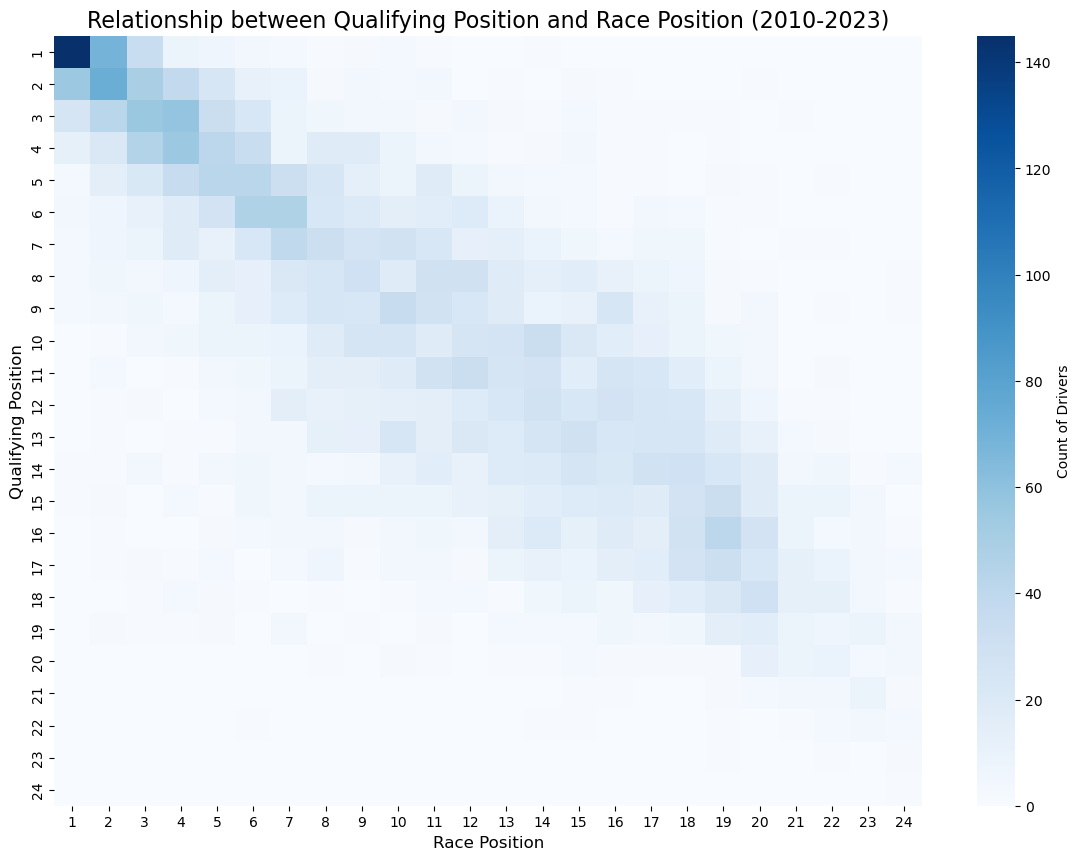

In [19]:
# Generate and Display the Heatmap
print("Generating frequency heatmap...")
plt.figure(figsize=(14, 10))
sns.heatmap(
    contingency_table,
    cmap='Blues', 
    cbar_kws={'label': 'Count of Drivers'} # Label for the color bar
)
plt.title('Relationship between Qualifying Position and Race Position (2010-2023)', fontsize=16)
plt.xlabel('Race Position', fontsize=12)
plt.ylabel('Qualifying Position', fontsize=12)
plt.show()

###  Section 5.2 — Season-by-Season Correlation Analysis Vis

Calculates Spearman's Rank Correlation (ρ) and Contingency Coefficient (C) for each 
individual season from 2006–2023. This validates that the qualifying-race relationship 
is not an artefact of averaging — it holds true every single year across different 
technical regulations and team dominance eras.

In [20]:
from scipy.stats import chi2_contingency

# Use a clean copy of the already-loaded master dataframe
seasonal_df_raw = f1_df.copy()

seasonal_df_raw['Pos_q'] = pd.to_numeric(seasonal_df_raw['Pos_q'], errors='coerce')
seasonal_df_raw['Pos_race'] = pd.to_numeric(seasonal_df_raw['Pos_race'], errors='coerce')
seasonal_df_raw = seasonal_df_raw.dropna(subset=['Pos_q', 'Pos_race'])
seasonal_df_raw['Pos_q'] = seasonal_df_raw['Pos_q'].astype(int)
seasonal_df_raw['Pos_race'] = seasonal_df_raw['Pos_race'].astype(int)

In [21]:
# Calculate Spearman's Rho and Contingency Coefficient (C) for Each Season
from scipy.stats import spearmanr

seasonal_results = []

for season, group in seasonal_df_raw.groupby('season'):
    # Use scipy for Spearman so we get both rho AND the p-value
    clean = group[['Pos_q', 'Pos_race']].dropna()
    rho, p_value = spearmanr(clean['Pos_q'], clean['Pos_race'])

    # Calculate Contingency Coefficient (C)
    contingency_table = pd.crosstab(
        clean['Pos_q'].astype(int),
        clean['Pos_race'].astype(int)
    )
    
    if not contingency_table.empty and contingency_table.sum().sum() > 0 and min(contingency_table.shape) > 1:
        chi2, p_chi, dof, expected = chi2_contingency(contingency_table)
        n = clean.shape[0]
        season_c = np.sqrt(chi2 / (n + chi2))   # renamed to season_c
    else:
        season_c = np.nan                         # renamed to season_c

    seasonal_results.append({
        'Season': season,
        'Spearman ρ': round(rho, 4),
        'p-value (ρ)': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.001 else 'No',
        'Contingency C': round(season_c, 4)      # renamed to season_c
    })

seasonal_df = pd.DataFrame(seasonal_results)
print("\n--- Seasonal Correlation Results ---")
print(seasonal_df.to_string(index=False))


--- Seasonal Correlation Results ---
 Season  Spearman ρ  p-value (ρ) Significant  Contingency C
   2006      0.7726          0.0         Yes         0.8343
   2007      0.8129          0.0         Yes         0.8684
   2008      0.6686          0.0         Yes         0.8454
   2009      0.7195          0.0         Yes         0.8254
   2010      0.8088          0.0         Yes         0.8522
   2011      0.8510          0.0         Yes         0.8681
   2012      0.7619          0.0         Yes         0.8515
   2013      0.7960          0.0         Yes         0.8299
   2014      0.7937          0.0         Yes         0.8475
   2015      0.7905          0.0         Yes         0.8544
   2016      0.8094          0.0         Yes         0.8454
   2017      0.7943          0.0         Yes         0.8359
   2018      0.7991          0.0         Yes         0.8206
   2019      0.7570          0.0         Yes         0.8352
   2020      0.7528          0.0         Yes         0.8371
  

In [22]:
# Overall correlation across entire dataset
all_clean = f1_df[['Pos_q', 'Pos_race']].dropna()
overall_rho, overall_p = spearmanr(all_clean['Pos_q'], all_clean['Pos_race'])
print(f"\n=== OVERALL (2006-2023) ===")
print(f"Spearman ρ = {overall_rho:.4f}, p = {overall_p:.2e}, n = {len(all_clean)}")


=== OVERALL (2006-2023) ===
Spearman ρ = 0.7750, p = 0.00e+00, n = 6005


In [23]:
# Overall Contingency C for the full 2006-2023 dataset
overall_c = contingency_c(seasonal_df_raw['Pos_q'], seasonal_df_raw['Pos_race'])
print(f"Overall Contingency C (2006-2023): {overall_c}")

Overall Contingency C (2006-2023): 0.7731



Generating season-by-season analysis plot...


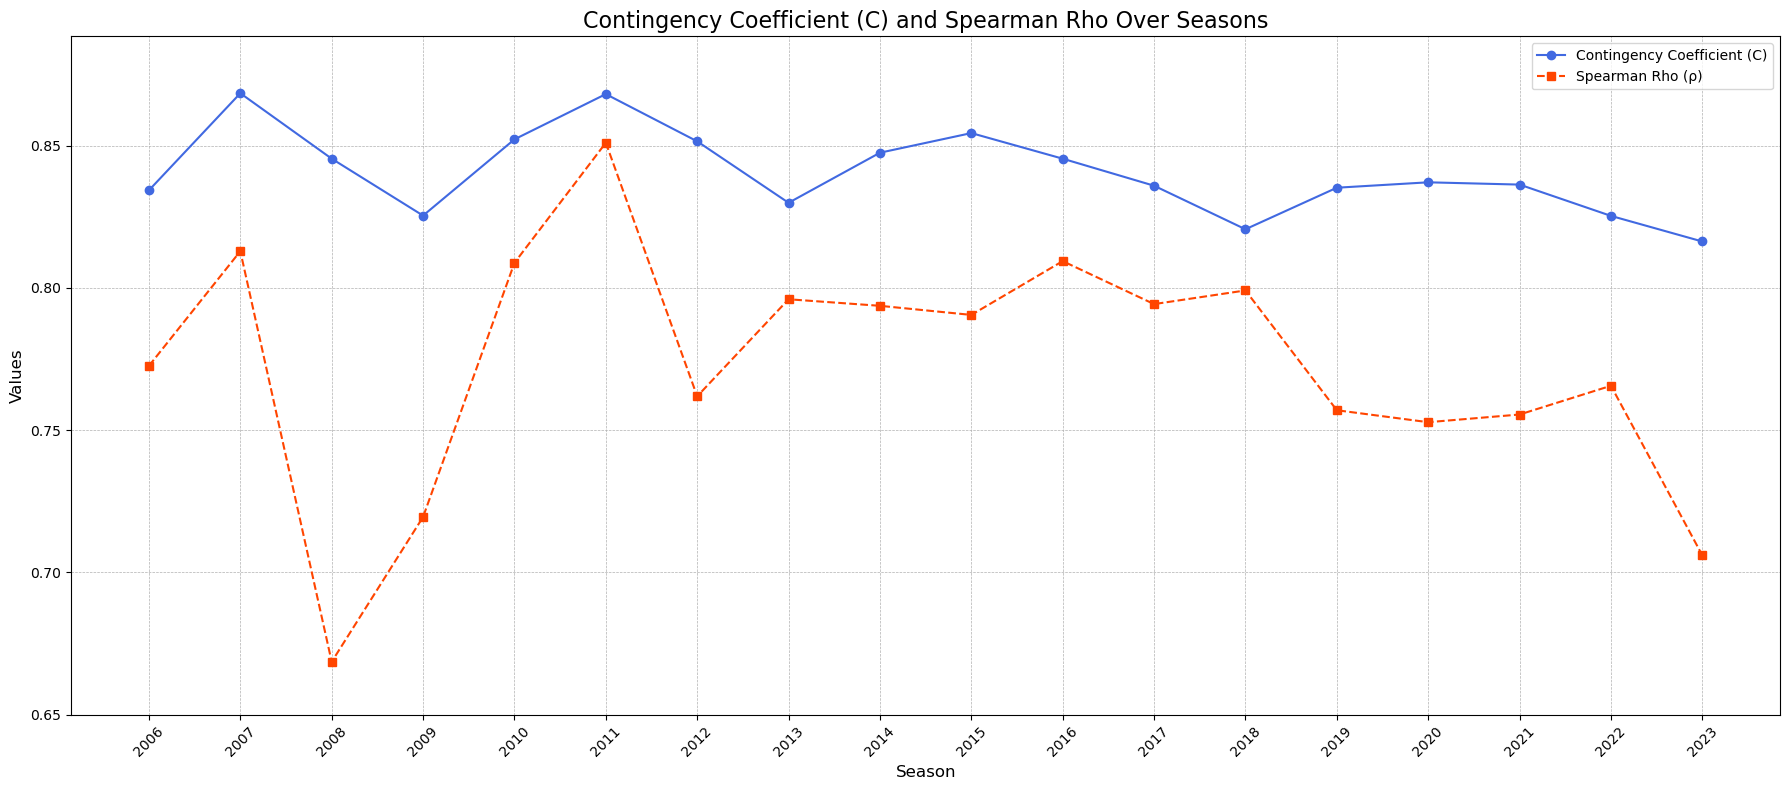

In [24]:
# Generate and Display the Line Plot
print("\nGenerating season-by-season analysis plot...")
fig, ax = plt.subplots(figsize=(18, 8))

# Plot Contingency Coefficient (C)
ax.plot(
    seasonal_df['Season'],
    seasonal_df['Contingency C'],
    marker='o',
    linestyle='-',
    color='royalblue',
    label='Contingency Coefficient (C)'
)

# Plot Spearman Rho
ax.plot(
    seasonal_df['Season'],
    seasonal_df['Spearman ρ'],
    marker='s',
    linestyle='--',
    color='orangered',
    label='Spearman Rho (ρ)'
)

y_min = 0.65
y_max = seasonal_df[['Spearman ρ', 'Contingency C']].max().max() + 0.02
ax.set_ylim(y_min, y_max)

ax.set_title('Contingency Coefficient (C) and Spearman Rho Over Seasons', fontsize=16)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Values', fontsize=12)
ax.set_xticks(seasonal_df['Season'])
ax.set_xticklabels(seasonal_df['Season'], rotation=45)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

### Section 5.3 — Multi-Variable Session Correlation Analysis
Computes a Spearman correlation matrix across all five positional session variables 
(P1, P2, P3, Qualifying, Race Start) against final race position. This identifies 
which session is the strongest individual predictor of race outcome and justifies 
why qualifying is the focus of this study over practice sessions.


In [25]:
corr_df = f1_df.copy()

# Select all session position columns and the target
session_cols = ['Pos_p1', 'Pos_p2', 'Pos_p3', 'Pos_q', 'Race_Start_pos', 'Pos_race']

# Convert all to numeric
for col in session_cols:
    corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')

corr_df_clean = corr_df[session_cols].dropna()

# Build a Spearman correlation matrix manually (pairwise)
n = len(session_cols)
corr_matrix = pd.DataFrame(index=session_cols, columns=session_cols, dtype=float)

for col_a in session_cols:
    for col_b in session_cols:
        rho, _ = spearmanr(corr_df_clean[col_a], corr_df_clean[col_b])
        corr_matrix.loc[col_a, col_b] = round(rho, 3)

print("Spearman Correlation Matrix (all sessions vs Pos_race):")
print(corr_matrix)

Spearman Correlation Matrix (all sessions vs Pos_race):
                Pos_p1  Pos_p2  Pos_p3  Pos_q  Race_Start_pos  Pos_race
Pos_p1           1.000   0.532   0.405  0.497           0.481     0.419
Pos_p2           0.532   1.000   0.504  0.669           0.653     0.588
Pos_p3           0.405   0.504   1.000  0.592           0.590     0.521
Pos_q            0.497   0.669   0.592  1.000           0.971     0.752
Race_Start_pos   0.481   0.653   0.590  0.971           1.000     0.742
Pos_race         0.419   0.588   0.521  0.752           0.742     1.000


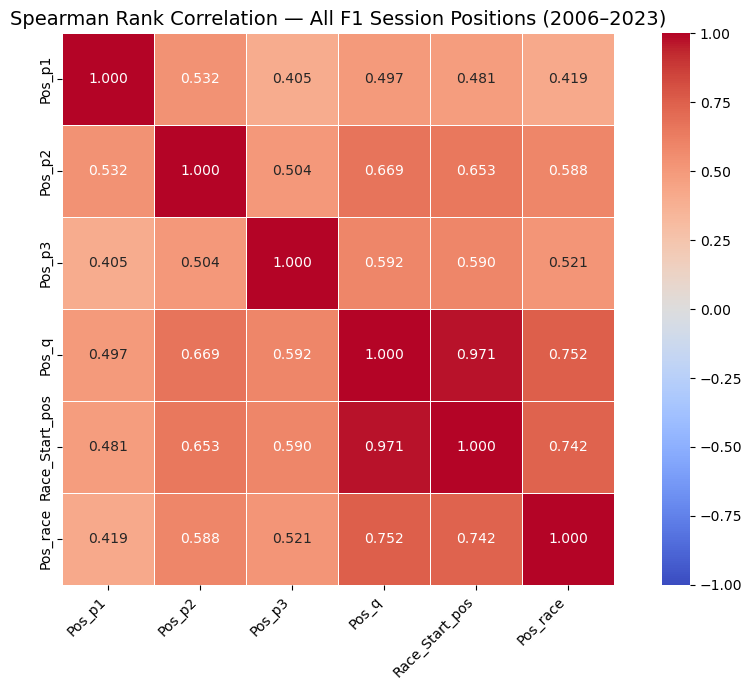


Correlation with Final Race Position (Pos_race):
Pos_p1            0.419
Pos_p3            0.521
Pos_p2            0.588
Race_Start_pos    0.742
Pos_q             0.752
Pos_race          1.000
Name: Pos_race, dtype: float64


In [26]:
# visualising as a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix.astype(float),
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Spearman Rank Correlation — All F1 Session Positions (2006–2023)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the row for Pos_race only for easy reference
print("\nCorrelation with Final Race Position (Pos_race):")
print(corr_matrix['Pos_race'].sort_values())

### Section 5.4 Ordinal Logistic Regression (OLR)
Fits an OLR model using qualifying position as the sole predictor of race finishing 
category (Podium / Points / Outside Points). This provides a rigorous statistical 
test beyond correlation — confirming that qualifying position is a statistically 
significant ordinal predictor of race outcome (p < 0.001).

In [27]:
# import and reload the clean data
from statsmodels.miscmodels.ordinal_model import OrderedModel

olr_df = f1_df.copy()

In [28]:
# remove rows and keep only rows where race/qualifying positions are valid numeric vals
olr_df['Pos_q'] = pd.to_numeric(olr_df['Pos_q'], errors='coerce')
olr_df['Pos_race'] = pd.to_numeric(olr_df['Pos_race'], errors='coerce')
olr_df = olr_df.dropna(subset=['Pos_q', 'Pos_race'])
olr_df = olr_df[olr_df['Pos_q'] > 0]

In [29]:
# bin race finishing pos into 3 categories: 1-5, 6-10, 11+
# Group 1: 1-3 podium, Group 2: 4-10 points finishers, Group 3: 11+ non-points finishers
def bin_position(pos):
    if pos <= 3:
        return 'Podium (1-3)'
    elif pos <= 10:
        return 'Points (4-10)'
    else:
        return 'Outside Points (11+)'

olr_df['race_group'] = olr_df['Pos_race'].apply(bin_position)


In [30]:
# convert to ordered categorical for OLR (bcs order matters)
from pandas.api.types import CategoricalDtype
order = CategoricalDtype(
    categories=['Outside Points (11+)', 'Points (4-10)', 'Podium (1-3)'],
    ordered=True
)
olr_df['race_group'] = olr_df['race_group'].astype(order)

print("Race group distribution:")
print(olr_df['race_group'].value_counts().sort_index())

Race group distribution:
race_group
Outside Points (11+)    2530
Points (4-10)           2428
Podium (1-3)            1047
Name: count, dtype: int64


In [31]:
# fit the OLR model
# predict the race grp from the qualifying position
model = OrderedModel(
    olr_df['race_group'],
    olr_df[['Pos_q']],
    distr='logit'
)
result = model.fit(method='bfgs', disp=False)

print(result.summary())

                             OrderedModel Results                             
Dep. Variable:             race_group   Log-Likelihood:                -4097.0
Model:                   OrderedModel   AIC:                             8200.
Method:            Maximum Likelihood   BIC:                             8220.
Date:                Sat, 20 Jun 2026                                         
Time:                        17:53:22                                         
No. Observations:                6005                                         
Df Residuals:                    6002                                         
Df Model:                           1                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Pos_q                                 -0.3629      0.007    -49.908      0.000     

In [32]:
# extarct and display key results from the OLR model
print("=== OLR Key Results ===")
print(f"Qualifying Position coefficient: {result.params['Pos_q']:.4f}")
print(f"p-value: {result.pvalues['Pos_q']:.6f}")
print(f"Pseudo R-squared (McFadden): {result.prsquared:.4f}")
print()
print("Interpretation:")
print(f"For every 1 position drop in qualifying, the log-odds of finishing")
print(f"in a better race group changes by {result.params['Pos_q']:.4f}.")
print(f"The model is statistically significant (p < 0.001).")

=== OLR Key Results ===
Qualifying Position coefficient: -0.3629
p-value: 0.000000
Pseudo R-squared (McFadden): 0.3407

Interpretation:
For every 1 position drop in qualifying, the log-odds of finishing
in a better race group changes by -0.3629.
The model is statistically significant (p < 0.001).


###  Section 6.0 Team Reliability vs. Pace Quadrant Analysis
Proposes an original analytical framework that decomposes team performance into two 
independent dimensions: raw pace (average qualifying position) and mechanical 
reliability (DNF rate). This addresses the key limitation of the original case study, 
which does not account for DNF events as a confounding variable weakening the 
qualifying-race correlation.

In [33]:
# Load and Filter the Dataset 
# analyse the modern Turbo-Hybrid era for relevance
f1_hybrid_era = f1_df[(f1_df['season'] >= 2014) & (f1_df['season'] <= 2021)].copy()

# Remove noise rows — real team names never start with '*' or 'Note'
f1_hybrid_era = f1_hybrid_era[~f1_hybrid_era['Car'].str.startswith(('*', 'Note'), na=False)]

In [34]:
team_starts = f1_hybrid_era['Car'].value_counts()
team_dnfs = f1_hybrid_era[f1_hybrid_era['is_dnf'] == True]['Car'].value_counts()
team_dnf_rate = (team_dnfs / team_starts * 100).fillna(0)

print(f"Total DNFs detected in hybrid era: {f1_hybrid_era['is_dnf'].sum()}")
print(f"DNF rate per team:\n{team_dnf_rate.sort_values(ascending=False)}")

Total DNFs detected in hybrid era: 1087
DNF rate per team:
Car
Lotus Mercedes               39.473684
Caterham Renault             38.235294
McLaren Honda                31.666667
Lotus Renault                31.578947
Toro Rosso                   30.000000
STR Renault                  27.631579
Toro Rosso Ferrari           23.809524
Sauber Ferrari               23.000000
Renault                      22.500000
Haas Ferrari                 21.971253
Red Bull Racing TAG Heuer    21.774194
MRT Mercedes                 19.047619
Scuderia Toro Rosso Honda    16.666667
McLaren Renault              16.101695
Red Bull Racing Renault      14.473684
Racing Point BWT Mercedes    14.473684
AlphaTauri Honda             14.102564
Aston Martin Mercedes        13.636364
Marussia Ferrari             13.636364
Force India Mercedes         13.500000
Williams Mercedes            13.479624
Ferrari                      12.187500
Alpine Renault               11.363636
Red Bull Racing Honda        10.833333
A

In [35]:
# Calculate Average Qualifying Position per Team 
f1_hybrid_era['Pos_q'] = pd.to_numeric(f1_hybrid_era['Pos_q'], errors='coerce')
team_avg_qualifying = f1_hybrid_era.groupby('Car')['Pos_q'].mean()

In [36]:
# Integrate everything into a single dataframe
team_performance = pd.DataFrame({
    'avg_qualifying_pos': team_avg_qualifying,
    'dnf_rate_percent': team_dnf_rate
}).dropna()

# Filter for teams with a significant number of starts for a fair comparison
main_teams = team_starts[team_starts > 50].index
team_performance = team_performance.loc[main_teams]

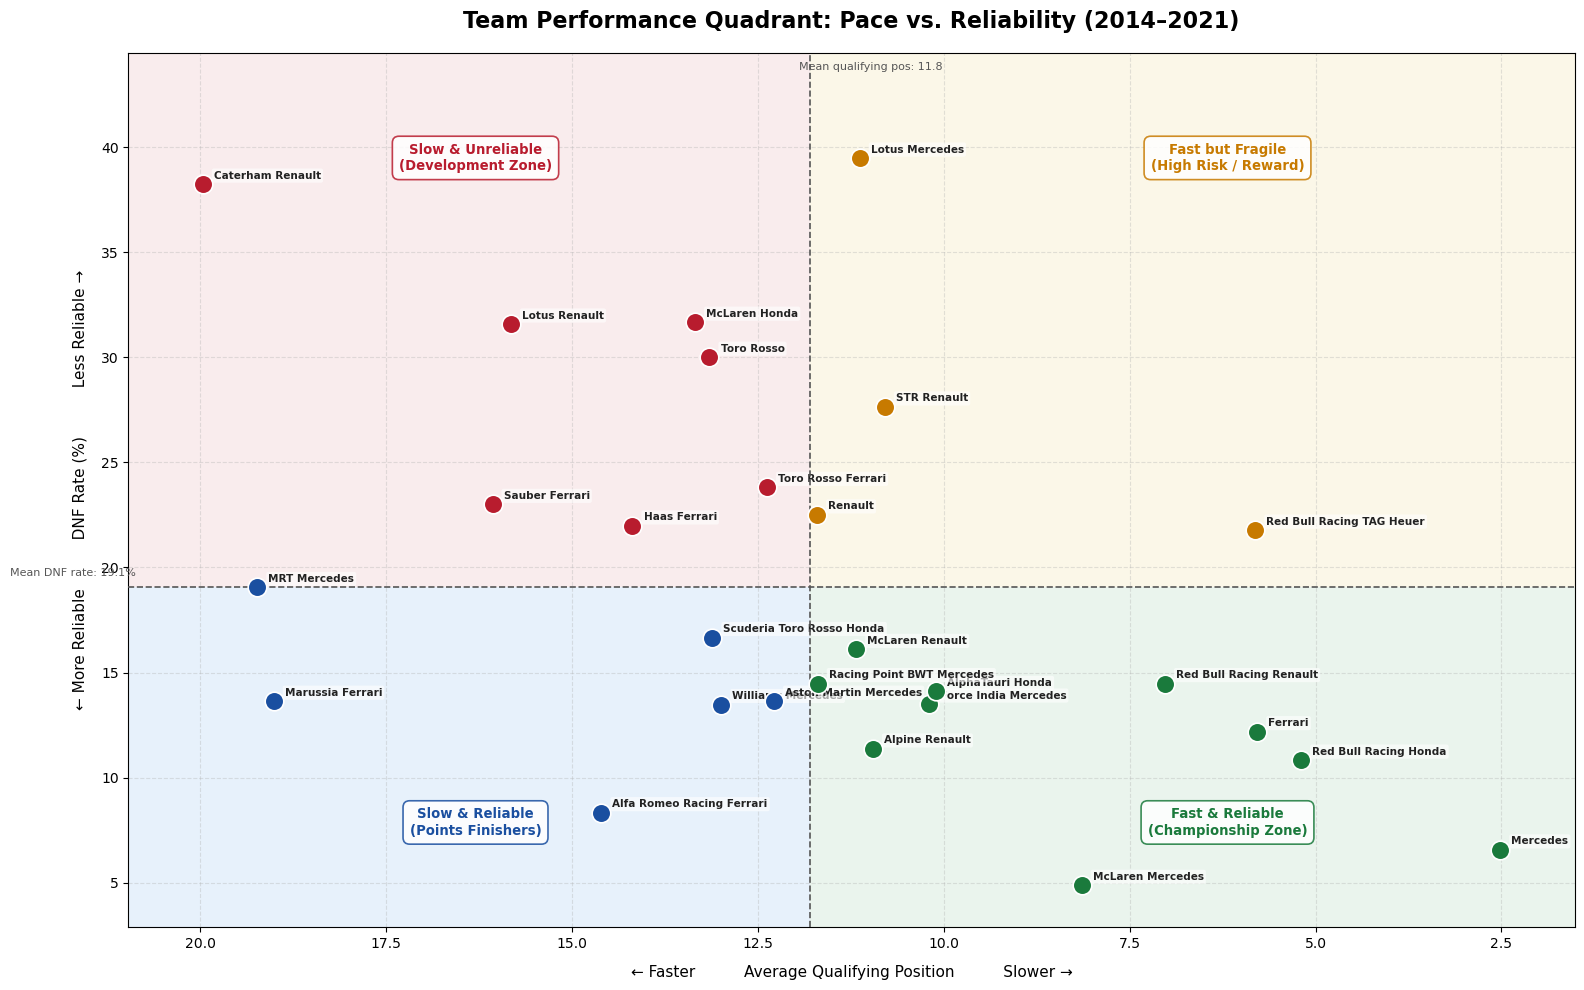

In [37]:
# Visualize as a Quadrant Scatter Plot
fig, ax = plt.subplots(figsize=(16, 10))

# ── Quadrant background shading ──────────────────────────────────────────────
# Get axis limits first by letting matplotlib auto-scale, then we'll apply shading
# We need the data range to draw background rectangles
x_min_data = team_performance['avg_qualifying_pos'].min() - 1
x_max_data = team_performance['avg_qualifying_pos'].max() + 1
y_min_data = team_performance['dnf_rate_percent'].min() - 2
y_max_data = team_performance['dnf_rate_percent'].max() + 5

avg_q   = team_performance['avg_qualifying_pos'].mean()
avg_dnf = team_performance['dnf_rate_percent'].mean()

# Because x-axis is inverted: LEFT on screen = high avg_q = SLOW
#                              RIGHT on screen = low avg_q  = FAST
# So quadrant shading uses raw data coordinates (before inversion)
# Bottom-right in data space (low x, low y) = Fast & Reliable  → green
# Bottom-left  in data space (high x, low y) = Slow & Reliable → blue
# Top-right    in data space (low x, high y) = Fast but Fragile → orange
# Top-left     in data space (high x, high y)= Slow & Unreliable → red

from matplotlib.patches import Rectangle

ax.add_patch(Rectangle((x_min_data, y_min_data), avg_q - x_min_data, avg_dnf - y_min_data,
                         facecolor='#d4edda', alpha=0.4, zorder=0))  # Fast & Reliable (green tint)
ax.add_patch(Rectangle((avg_q, y_min_data), x_max_data - avg_q, avg_dnf - y_min_data,
                         facecolor='#cce5ff', alpha=0.4, zorder=0))  # Slow & Reliable (blue tint)
ax.add_patch(Rectangle((x_min_data, avg_dnf), avg_q - x_min_data, y_max_data - avg_dnf,
                         facecolor='#fff3cd', alpha=0.4, zorder=0))  # Fast but Fragile (orange tint)
ax.add_patch(Rectangle((avg_q, avg_dnf), x_max_data - avg_q, y_max_data - avg_dnf,
                         facecolor='#f8d7da', alpha=0.4, zorder=0))  # Slow & Unreliable (red tint)

# ── Assign each team a color based on which quadrant it falls in ──────────────
def get_quadrant_color(row, avg_q, avg_dnf):
    fast = row['avg_qualifying_pos'] < avg_q
    reliable = row['dnf_rate_percent'] < avg_dnf
    if fast and reliable:
        return '#1a7a3c'      # dark green — Championship Zone
    elif not fast and reliable:
        return '#1a4fa0'      # dark blue  — Points Finishers
    elif fast and not reliable:
        return '#c77a00'      # dark orange — High Risk
    else:
        return '#b81c2e'      # dark red   — Development Zone

team_performance['color'] = team_performance.apply(
    lambda row: get_quadrant_color(row, avg_q, avg_dnf), axis=1
)

# ── Plot dots ────────────────────────────────────────────────────────────────
for team in team_performance.index:
    ax.scatter(
        team_performance.loc[team, 'avg_qualifying_pos'],
        team_performance.loc[team, 'dnf_rate_percent'],
        color=team_performance.loc[team, 'color'],
        s=180,
        zorder=5,
        edgecolors='white',
        linewidths=1.2
    )

# ── Team name labels with smart offset to reduce overlap ─────────────────────
for team in team_performance.index:
    x = team_performance.loc[team, 'avg_qualifying_pos']
    y = team_performance.loc[team, 'dnf_rate_percent']
    ax.annotate(
        team,
        xy=(x, y),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=7.5,
        color='#222222',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='none')
    )

# ── Quadrant divider lines ────────────────────────────────────────────────────
ax.axvline(avg_q, color='#555555', linestyle='--', linewidth=1.2, zorder=3)
ax.axhline(avg_dnf, color='#555555', linestyle='--', linewidth=1.2, zorder=3)

# ── Quadrant corner labels using axis proportions ────────────────────────────
quadrant_labels = [
    (0.76, 0.12, 'Fast & Reliable\n(Championship Zone)',  '#1a7a3c'),
    (0.24, 0.12, 'Slow & Reliable\n(Points Finishers)',    '#1a4fa0'),
    (0.76, 0.88, 'Fast but Fragile\n(High Risk / Reward)', '#c77a00'),
    (0.24, 0.88, 'Slow & Unreliable\n(Development Zone)',  '#b81c2e'),
]

for x_prop, y_prop, label, color in quadrant_labels:
    ax.text(
        x_prop, y_prop, label,
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=9.5, color=color, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  alpha=0.85, edgecolor=color, linewidth=1.2)
    )

# ── Axis labels & mean annotation ────────────────────────────────────────────
ax.invert_xaxis()
ax.set_xlim(x_max_data, x_min_data)
ax.set_ylim(y_min_data, y_max_data)

ax.set_title('Team Performance Quadrant: Pace vs. Reliability (2014–2021)',
             fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('← Faster          Average Qualifying Position          Slower →',
              fontsize=11, labelpad=10)
ax.set_ylabel('← More Reliable          DNF Rate (%)          Less Reliable →',
              fontsize=11, labelpad=10)

# Add mean reference annotations on the divider lines
ax.text(avg_q + 0.15, y_max_data - 0.8,
        f'Mean qualifying pos: {avg_q:.1f}',
        fontsize=8, color='#555555', ha='left')
ax.text(x_max_data - 0.1, avg_dnf + 0.5,
        f'Mean DNF rate: {avg_dnf:.1f}%',
        fontsize=8, color='#555555', ha='right')

ax.grid(True, linestyle='--', alpha=0.35)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#ffffff')

plt.tight_layout()
plt.show()

### Benchmarking!

Actual unique values:    ['Podium (1-3)' 'Points (4-10)' 'Outside Points (11+)']
Predicted unique values: ['Podium (1-3)' 'Points (4-10)' 'Outside Points (11+)']

Naive baseline accuracy: 42.1%
OLR model accuracy:      70.9%
Improvement:             +28.8 percentage points

Per-class breakdown:
                      precision    recall  f1-score   support

Outside Points (11+)       0.78      0.74      0.76      2530
       Points (4-10)       0.64      0.70      0.67      2428
        Podium (1-3)       0.72      0.65      0.69      1047

            accuracy                           0.71      6005
           macro avg       0.71      0.70      0.70      6005
        weighted avg       0.71      0.71      0.71      6005



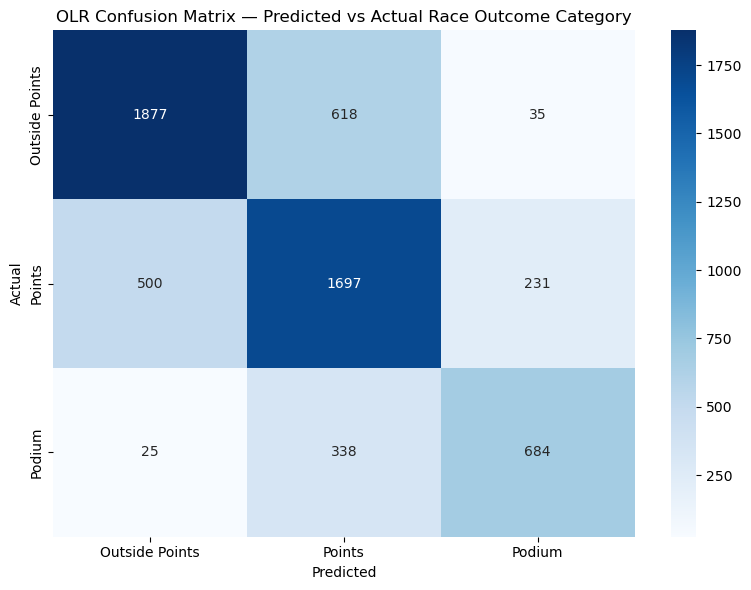

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Get predicted probabilities from OLR
pred_probs = result.predict(olr_df[['Pos_q']])

# Map column indices back to category names
# statsmodels returns columns 0,1,2 — map them to the actual category labels
category_map = {
    0: 'Outside Points (11+)',
    1: 'Points (4-10)',
    2: 'Podium (1-3)'
}

# Get the index of the highest probability then map to label
predicted_classes = pred_probs.idxmax(axis=1).map(category_map)
actual_classes = olr_df['race_group'].astype(str)

# Verify they now match
print("Actual unique values:   ", actual_classes.unique())
print("Predicted unique values:", predicted_classes.unique())
print()

# Overall accuracy
olr_accuracy = accuracy_score(actual_classes, predicted_classes)

# Naive baseline — always guess the most common class
most_common = actual_classes.value_counts().index[0]
naive_accuracy = (actual_classes == most_common).mean()

print(f"Naive baseline accuracy: {naive_accuracy*100:.1f}%")
print(f"OLR model accuracy:      {olr_accuracy*100:.1f}%")
print(f"Improvement:             +{(olr_accuracy - naive_accuracy)*100:.1f} percentage points")
print()

# Per class breakdown
label_order = ['Outside Points (11+)', 'Points (4-10)', 'Podium (1-3)']
print("Per-class breakdown:")
print(classification_report(actual_classes, predicted_classes, labels=label_order))

# Confusion matrix
cm = confusion_matrix(actual_classes, predicted_classes, labels=label_order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Outside Points', 'Points', 'Podium'],
            yticklabels=['Outside Points', 'Points', 'Podium'])
plt.title('OLR Confusion Matrix — Predicted vs Actual Race Outcome Category')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/olr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()